# 03c — Klasyczne ML: eksperymenty 4–5 i wyniki końcowe

Stacking, transfer cross-dataset, wyniki na teście. Wymaga `TW_FEATURES.pkl` (03a) oraz `exp1_grid_twitteremo.csv` i `exp3_handoff.json` (03b).

## Setup

In [1]:
import os
import time
import json
import pickle
import warnings
from pathlib import Path
from typing import Any, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, hstack as sparse_hstack, issparse

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier,
)
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.metrics import (
    f1_score, hamming_loss, jaccard_score, accuracy_score, precision_score, recall_score,
)
from sklearn.model_selection import KFold
import lightgbm as lgb

from thesis_lib import (evaluate, cache_features, optimal_thresholds,
                        log_runs_from_df, bootstrap_f1_ci as f1_macro_ci)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300

print(f"sklearn, lightgbm, gensim — wszystkie klasyczne, bez transformerów.")

sklearn, lightgbm, gensim — wszystkie klasyczne, bez transformerów.


In [2]:
# --- Constants ---
EMOTIONS = ["radość", "smutek", "zaufanie", "wstręt", "strach", "gniew", "przeczuwanie", "zdziwienie"]
RANDOM_STATE = 42

PROCESSED_DIR = Path("../data/processed")
CACHE_DIR     = Path("../data/features")
RESULTS_DIR   = Path("../data/results")
FIGURES_DIR   = Path("../figures")
for d in [CACHE_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Cache:   {CACHE_DIR}")
print(f"Results: {RESULTS_DIR}")
print(f"Figures: {FIGURES_DIR}")

Cache:   ../data/features
Results: ../data/results
Figures: ../figures


In [3]:
# --- Load processed data ---
tw_train = pd.read_csv(PROCESSED_DIR / "twitteremo_train.csv").reset_index(drop=True)
tw_val   = pd.read_csv(PROCESSED_DIR / "twitteremo_val.csv").reset_index(drop=True)
tw_test  = pd.read_csv(PROCESSED_DIR / "twitteremo_test.csv").reset_index(drop=True)

go_train = pd.read_csv(PROCESSED_DIR / "go_emotions_train.csv").reset_index(drop=True)
go_val   = pd.read_csv(PROCESSED_DIR / "go_emotions_val.csv").reset_index(drop=True)
go_test  = pd.read_csv(PROCESSED_DIR / "go_emotions_test.csv").reset_index(drop=True)

for df in [tw_train, tw_val, tw_test, go_train, go_val, go_test]:
    df["clean_text"] = df["clean_text"].fillna("")

y_tw_train = tw_train[EMOTIONS].values
y_tw_val   = tw_val[EMOTIONS].values
y_tw_test  = tw_test[EMOTIONS].values
y_go_train = go_train[EMOTIONS].values
y_go_val   = go_val[EMOTIONS].values
y_go_test  = go_test[EMOTIONS].values

print(f"TwitterEmo:    train={len(tw_train):,}, val={len(tw_val):,}, test={len(tw_test):,}")
print(f"GoEmotions PL: train={len(go_train):,}, val={len(go_val):,}, test={len(go_test):,}")

TwitterEmo:    train=28,684, val=5,737, test=1,435
GoEmotions PL: train=34,276, val=6,855, test=1,714


In [6]:
# --- Load artifacts from 03a (features) and 03b (Exp1/Exp3) ---
with open(CACHE_DIR / "TW_FEATURES.pkl", "rb") as f:
    TW_FEATURES = pickle.load(f)
tw_tfidf_word = TW_FEATURES["tfidf_word"]

tw_grid = pd.read_csv(RESULTS_DIR / "exp1_grid_twitteremo.csv")
best_per_rep = (tw_grid.loc[tw_grid.groupby("representation")["f1_macro"].idxmax()]
                .sort_values("f1_macro", ascending=False).reset_index(drop=True))
best_row = tw_grid.iloc[0]
best_rep, best_model_name = best_row["representation"], best_row["model"]

_h = json.load(open(RESULTS_DIR / "exp3_handoff.json"))
opt_metrics, default_metrics = _h["opt_metrics"], _h["default_metrics"]
print(f"best from Exp1: {best_rep} × {best_model_name}")

best from Exp1: tfidf_char × logreg


In [7]:
# --- MLflow tracking (file-based, no server) ---
import mlflow

# Newer MLflow refuses the file-store backend unless explicitly opted in.
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")

MLFLOW_DIR = Path("../mlruns").resolve()
mlflow.set_tracking_uri(f"file:{MLFLOW_DIR}")
mlflow.set_experiment("classical_ml_thesis")

print(f"MLflow -> {MLFLOW_DIR}  (eksperyment: classical_ml_thesis)")

MLflow -> /path/to/repo/mlruns  (eksperyment: classical_ml_thesis)


In [8]:
def find_optimal_thresholds(y_true, y_proba, labels=None):
    return optimal_thresholds(y_true, y_proba)

## 7. Eksperyment 4: stacking

Out-of-fold: 3 base learnery → meta-LogReg na konkatenacji prawdopodobieństw. Cecha bazowa fastText; base learnery LogReg / LightGBM / MLP.

In [9]:
def stacking_oof(
    estimators: list[tuple[str, Any]],
    X_train, y_train, X_val, X_test,
    n_splits: int = 5,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """OOF probability predictions for stacking."""
    n_train, n_val, n_test = X_train.shape[0], X_val.shape[0], X_test.shape[0]
    n_labels = y_train.shape[1]
    n_est = len(estimators)
    oof_train = np.zeros((n_train, n_est * n_labels))
    oof_val   = np.zeros((n_val,   n_est * n_labels))
    oof_test  = np.zeros((n_test,  n_est * n_labels))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    for ei, (name, est) in enumerate(estimators):
        col_lo, col_hi = ei * n_labels, (ei + 1) * n_labels
        print(f"  Base learner: {name}")
        for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(n_train))):
            clf = OneVsRestClassifier(est, n_jobs=1)
            clf.fit(X_train[tr_idx], y_train[tr_idx])
            oof_train[va_idx, col_lo:col_hi] = clf.predict_proba(X_train[va_idx])
        clf_full = OneVsRestClassifier(est, n_jobs=1)
        clf_full.fit(X_train, y_train)
        oof_val[:,  col_lo:col_hi] = clf_full.predict_proba(X_val)
        oof_test[:, col_lo:col_hi] = clf_full.predict_proba(X_test)

    return oof_train, oof_val, oof_test


X_tr_st = TW_FEATURES["fasttext"]["train"]
X_va_st = TW_FEATURES["fasttext"]["val"]
X_te_st = TW_FEATURES["fasttext"]["test"]

base_estimators = [
    ("logreg",   LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced",
                                    solver="liblinear", random_state=RANDOM_STATE)),
    ("lightgbm", lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, n_jobs=-1,
                                    class_weight="balanced", random_state=RANDOM_STATE, verbose=-1)),
    ("mlp",      MLPClassifier(hidden_layer_sizes=(128,), max_iter=50,
                               early_stopping=True, random_state=RANDOM_STATE)),
]

print("Generating OOF predictions...")
oof_tr, oof_va, oof_te = stacking_oof(base_estimators, X_tr_st, y_tw_train, X_va_st, X_te_st)

meta = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE))
meta.fit(oof_tr, y_tw_train)
y_proba_stack_val = meta.predict_proba(oof_va)

y_pred_stack_default = (y_proba_stack_val >= 0.5).astype(int)
opt_thr_stack = find_optimal_thresholds(y_tw_val, y_proba_stack_val, EMOTIONS)
y_pred_stack_opt = (y_proba_stack_val >= opt_thr_stack).astype(int)

m_stack_def = evaluate(y_tw_val, y_pred_stack_default)
m_stack_opt = evaluate(y_tw_val, y_pred_stack_opt)

stack_df = pd.DataFrame([
    {"setup": "best single model (Eksp. 3, optimal thr)", **opt_metrics},
    {"setup": "stacking (default thr=0.5)",                **m_stack_def},
    {"setup": "stacking (optimal thresholds)",              **m_stack_opt},
])
stack_df.to_csv(RESULTS_DIR / "exp4_stacking.csv", index=False)
display(stack_df[["setup", "f1_macro", "f1_micro", "jaccard_macro", "hamming_loss"]])

Generating OOF predictions...
  Base learner: logreg


  Base learner: lightgbm


  Base learner: mlp


,setup,f1_macro,f1_micro,jaccard_macro,hamming_loss
0,"best single model (Eksp. 3, optimal thr)",0.469792,0.577668,0.319069,0.123453
1,stacking (default thr=0.5),0.221389,0.424617,0.143360,0.115500
2,stacking (optimal thresholds),0.357409,0.489374,0.235181,0.174329


### Eksperyment 4b: stacking v2 — silne base learnery

Stacking v1 przegrał z pojedynczym modelem (0,335 vs 0,474). Hipoteza: winna słaba cecha bazowa, nie architektura. Te same 5-fold OOF + meta-LogReg, ale base learnery na char TF-IDF / word TF-IDF / fastText.

In [10]:
def stacking_oof_multi(
    estimators: list[tuple[str, Any, dict]],
    y_train: np.ndarray,
    n_splits: int = 5,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """OOF stacking where each base learner uses its own feature matrices.

    Args:
        estimators: List of (name, estimator, features) where features is the
            TW_FEATURES-style dict with "train"/"val"/"test" matrices.
        y_train: Multi-label train targets, shape (n_train, n_labels).
        n_splits: Number of OOF folds.

    Returns:
        Tuple (oof_train, oof_val, oof_test) of stacked probability features.
    """
    n_labels = y_train.shape[1]
    n_est = len(estimators)
    n_train = y_train.shape[0]
    oof_train = np.zeros((n_train, n_est * n_labels))
    oof_val   = np.zeros((estimators[0][2]["val"].shape[0],  n_est * n_labels))
    oof_test  = np.zeros((estimators[0][2]["test"].shape[0], n_est * n_labels))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    for ei, (name, est, feats) in enumerate(estimators):
        lo, hi = ei * n_labels, (ei + 1) * n_labels
        print(f"  Base learner: {name}")
        X_tr, X_va, X_te = feats["train"], feats["val"], feats["test"]
        for tr_idx, va_idx in kf.split(np.arange(n_train)):
            clf = OneVsRestClassifier(est, n_jobs=1)
            clf.fit(X_tr[tr_idx], y_train[tr_idx])
            oof_train[va_idx, lo:hi] = clf.predict_proba(X_tr[va_idx])
        clf_full = OneVsRestClassifier(est, n_jobs=1)
        clf_full.fit(X_tr, y_train)
        oof_val[:,  lo:hi] = clf_full.predict_proba(X_va)
        oof_test[:, lo:hi] = clf_full.predict_proba(X_te)
    return oof_train, oof_val, oof_test


base_v2 = [
    ("logreg_char", LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced",
                                       solver="liblinear", random_state=RANDOM_STATE),
     TW_FEATURES["tfidf_char"]),
    ("logreg_word", LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced",
                                       solver="liblinear", random_state=RANDOM_STATE),
     TW_FEATURES["tfidf_word"]),
    ("lightgbm_fasttext", lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, n_jobs=-1,
                                             class_weight="balanced", random_state=RANDOM_STATE,
                                             verbose=-1),
     TW_FEATURES["fasttext"]),
]

print("Generating OOF predictions (stacking v2)...")
oof_tr2, oof_va2, oof_te2 = stacking_oof_multi(base_v2, y_tw_train)

meta2 = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE))
meta2.fit(oof_tr2, y_tw_train)
p_va2 = meta2.predict_proba(oof_va2)
thr2 = find_optimal_thresholds(y_tw_val, p_va2, EMOTIONS)
m_va2 = evaluate(y_tw_val, (p_va2 >= thr2).astype(int))

p_te2 = meta2.predict_proba(oof_te2)
m_te2 = evaluate(y_tw_test, (p_te2 >= thr2).astype(int))

stack_v2_df = pd.DataFrame([
    {"setup": "best single model (Eksp. 3, optimal thr) [val]", **opt_metrics},
    {"setup": "stacking v1 fastText (optimal thr) [val]",        **m_stack_opt},
    {"setup": "stacking v2 silne bazy (optimal thr) [val]",      **m_va2},
    {"setup": "stacking v2 silne bazy (optimal thr) [test]",     **m_te2},
])
stack_v2_df.to_csv(RESULTS_DIR / "exp4_stacking_v2.csv", index=False)
display(stack_v2_df[["setup", "f1_macro", "f1_micro", "jaccard_macro", "hamming_loss"]])

Generating OOF predictions (stacking v2)...
  Base learner: logreg_char


  Base learner: logreg_word


  Base learner: lightgbm_fasttext


,setup,f1_macro,f1_micro,jaccard_macro,hamming_loss
0,"best single model (Eksp. 3, optimal thr) [val]",0.469792,0.577668,0.319069,0.123453
1,stacking v1 fastText (optimal thr) [val],0.357409,0.489374,0.235181,0.174329
2,stacking v2 silne bazy (optimal thr) [val],0.474162,0.589399,0.324696,0.120337
3,stacking v2 silne bazy (optimal thr) [test],0.454138,0.579805,0.308693,0.123606


## 8. Eksperyment 5: transfer cross-dataset

Macierz 3×3 (wiersz = train, kolumna = eval). Wspólny TF-IDF char(3,5) dopasowany na połączonych zbiorach train, LogReg, progi na val zbioru treningowego, train podpróbkowany do najmniejszego (CE).

In [11]:
# === Eksperyment 5: macierz transferu 3×3 (TW / GO / CE) ===
# Wiersz = zbiór TRENINGOWY, kolumna = zbiór EWALUACYJNY (zawsze split test).
# Trzy zbiory: TwitterEmo (natywny Twitter), GoEmotions PL (tłumaczony Reddit),
# CLARIN-Emo (natywne recenzje, anotacja ekspercka) — ten sam schemat 8 emocji Plutchika.


ce_train = pd.read_csv(PROCESSED_DIR / "clarin_emo_train.csv").reset_index(drop=True)
ce_val   = pd.read_csv(PROCESSED_DIR / "clarin_emo_val.csv").reset_index(drop=True)
ce_test  = pd.read_csv(PROCESSED_DIR / "clarin_emo_test.csv").reset_index(drop=True)
for _df in (ce_train, ce_val, ce_test):
    _df["tekst"] = _df["tekst"].fillna("")

# surowy tekst per zbiór: TW/CE -> 'tekst', GO -> 'text_pl'
DATASETS = {
    "TW": {"tr": tw_train["tekst"].fillna(""), "va": tw_val["tekst"].fillna(""), "te": tw_test["tekst"].fillna(""),
           "ytr": y_tw_train, "yva": y_tw_val, "yte": y_tw_test},
    "GO": {"tr": go_train["text_pl"].fillna(""), "va": go_val["text_pl"].fillna(""), "te": go_test["text_pl"].fillna(""),
           "ytr": y_go_train, "yva": y_go_val, "yte": y_go_test},
    "CE": {"tr": ce_train["tekst"], "va": ce_val["tekst"], "te": ce_test["tekst"],
           "ytr": ce_train[EMOTIONS].values, "yva": ce_val[EMOTIONS].values, "yte": ce_test[EMOTIONS].values},
}


def build_shared_vectorizer_3x3():
    """TF-IDF char(3,5) dopasowany na połączonych train wszystkich 3 zbiorów -> wspólna przestrzeń."""
    vec = TfidfVectorizer(max_features=30_000, ngram_range=(3, 5), analyzer="char_wb",
                          min_df=5, sublinear_tf=True, lowercase=True)
    vec.fit(pd.concat([DATASETS[d]["tr"] for d in DATASETS]))
    return vec


shared_vec = cache_features("cross_tfidf_char_3x3_vec", build_shared_vectorizer_3x3)

N_SUB = min(len(DATASETS[d]["ytr"]) for d in DATASETS)
_rng = np.random.default_rng(RANDOM_STATE)
print(f"Wspólny TF-IDF char: {len(shared_vec.get_feature_names_out()):,} cech | "
      f"podpróbkowanie train do N={N_SUB:,} (najmniejszy = CE)")

X_test = {d: shared_vec.transform(DATASETS[d]["te"]) for d in DATASETS}
X_val  = {d: shared_vec.transform(DATASETS[d]["va"]) for d in DATASETS}

cd_rows = []
transfer_matrix = pd.DataFrame(index=list(DATASETS), columns=list(DATASETS), dtype=float)
for tr in DATASETS:
    idx = _rng.choice(len(DATASETS[tr]["ytr"]), size=N_SUB, replace=False)
    X_tr = shared_vec.transform(DATASETS[tr]["tr"].iloc[idx])
    y_tr = DATASETS[tr]["ytr"][idx]
    clf = OneVsRestClassifier(LogisticRegression(
        max_iter=1000, C=1.0, class_weight="balanced",
        solver="liblinear", random_state=RANDOM_STATE))
    clf.fit(X_tr, y_tr)
    thr = find_optimal_thresholds(DATASETS[tr]["yva"], clf.predict_proba(X_val[tr]), EMOTIONS)
    for ev in DATASETS:
        y_pred = (clf.predict_proba(X_test[ev]) >= thr).astype(int)
        m = evaluate(DATASETS[ev]["yte"], y_pred)
        m["setup"] = f"{tr} → {ev}" + (" (in-domain)" if tr == ev else " (transfer)")
        m["train"], m["eval"] = tr, ev
        cd_rows.append(m)
        transfer_matrix.loc[tr, ev] = m["f1_macro"]

cd_df = pd.DataFrame(cd_rows)
cd_df.to_csv(RESULTS_DIR / "exp5_cross_dataset.csv", index=False)
transfer_matrix.to_csv(RESULTS_DIR / "exp5_transfer_matrix_3x3.csv")
print("\nMacierz F1-Macro (wiersz = train, kolumna = eval.test):")
display(transfer_matrix.round(3))
display(cd_df[["setup", "f1_macro", "f1_micro", "jaccard_macro", "hamming_loss"]])

Wspólny TF-IDF char: 30,000 cech | podpróbkowanie train do N=6,367 (najmniejszy = CE)



Macierz F1-Macro (wiersz = train, kolumna = eval.test):


,TW,GO,CE
TW,0.375,0.214,0.206
GO,0.184,0.446,0.182
CE,0.216,0.212,0.529


,setup,f1_macro,f1_micro,jaccard_macro,hamming_loss
0,TW → TW (in-domain),0.374756,0.518779,0.245872,0.142857
1,TW → GO (transfer),0.214279,0.289401,0.129762,0.168684
2,TW → CE (transfer),0.206184,0.261109,0.118815,0.213475
3,GO → TW (transfer),0.183975,0.195456,0.110143,0.163502
4,GO → GO (in-domain),0.445757,0.496954,0.296865,0.114425
5,GO → CE (transfer),0.182150,0.226647,0.104849,0.212580
6,CE → TW (transfer),0.216305,0.259471,0.126691,0.248606
7,CE → GO (transfer),0.212086,0.239037,0.123013,0.244239
8,CE → CE (in-domain),0.529234,0.625809,0.376308,0.172572


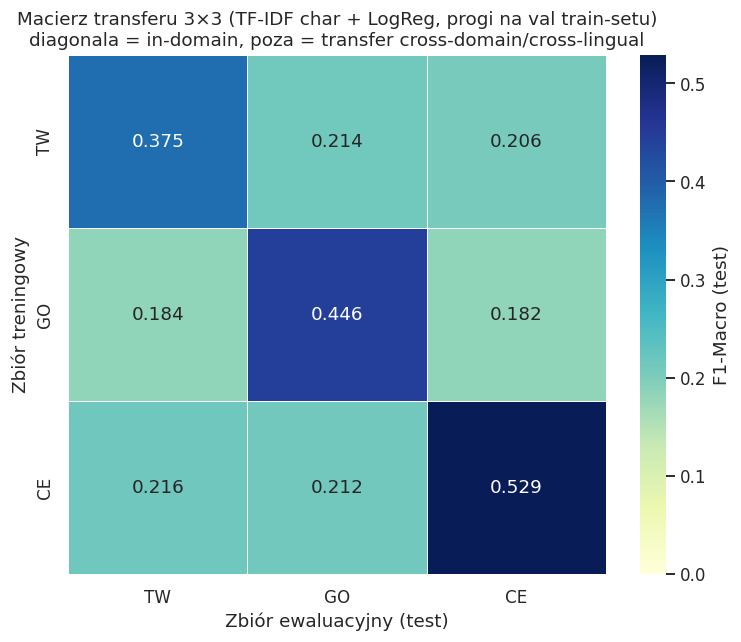

Średnia in-domain (diagonala) = 0.450 | średni transfer (poza diagonalą) = 0.202 | spadek = +0.247


In [12]:
# Heatmapa macierzy transferu 3×3 (diagonala = in-domain, off-diagonal = transfer)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(transfer_matrix.astype(float), annot=True, fmt=".3f", cmap="YlGnBu",
            cbar_kws={"label": "F1-Macro (test)"}, linewidths=0.5,
            vmin=0, vmax=float(np.nanmax(transfer_matrix.values)), ax=ax)
ax.set_xlabel("Zbiór ewaluacyjny (test)")
ax.set_ylabel("Zbiór treningowy")
ax.set_title("Macierz transferu 3×3 (TF-IDF char + LogReg, progi na val train-setu)\n"
             "diagonala = in-domain, poza = transfer cross-domain/cross-lingual")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp5_transfer_matrix_3x3.pdf", bbox_inches="tight")
plt.show()

# Skrót do tekstu: średni spadek transfer vs in-domain
_diag = np.diag(transfer_matrix.values.astype(float)).mean()
_off = transfer_matrix.values.astype(float)[~np.eye(3, dtype=bool)].mean()
print(f"Średnia in-domain (diagonala) = {_diag:.3f} | średni transfer (poza diagonalą) = {_off:.3f} "
      f"| spadek = {_diag - _off:+.3f}")

## 9. Wyniki końcowe na zbiorze testowym

In [13]:
# Final test set evaluation — full progression
print("=== Test set: progresja technik ===\n")

# Stacking on test
y_proba_stack_test = meta.predict_proba(oof_te)
y_pred_test_default = (y_proba_stack_test >= 0.5).astype(int)
y_pred_test_opt     = (y_proba_stack_test >= opt_thr_stack).astype(int)

# Best single model on test
clf_best = OneVsRestClassifier(LogisticRegression(
    max_iter=1000, C=1.0, class_weight="balanced",
    solver="liblinear", random_state=RANDOM_STATE,
))
clf_best.fit(TW_FEATURES[best_rep]["train"], y_tw_train)
y_proba_best_val   = clf_best.predict_proba(TW_FEATURES[best_rep]["val"])
opt_thr_best       = find_optimal_thresholds(y_tw_val, y_proba_best_val, EMOTIONS)
y_proba_best_test  = clf_best.predict_proba(TW_FEATURES[best_rep]["test"])
y_pred_best_test_default = (y_proba_best_test >= 0.5).astype(int)
y_pred_best_test_opt     = (y_proba_best_test >= opt_thr_best).astype(int)

# Majority baseline
y_majority = np.tile((y_tw_train.mean(axis=0) > 0.5).astype(int), (len(y_tw_test), 1))

final_rows = [
    {"setup": "1. Majority baseline",                                  **evaluate(y_tw_test, y_majority)},
    {"setup": f"2. LogReg + {best_rep} (próg=0.5)",                    **evaluate(y_tw_test, y_pred_best_test_default)},
    {"setup": f"3. LogReg + {best_rep} + optimal thr",                 **evaluate(y_tw_test, y_pred_best_test_opt)},
    {"setup": "4. Stacking (próg=0.5)",                                **evaluate(y_tw_test, y_pred_test_default)},
    {"setup": "5. Stacking + optimal thr (wynik negatywny)",                     **evaluate(y_tw_test, y_pred_test_opt)},
]
final_df = pd.DataFrame(final_rows)
final_df.to_csv(RESULTS_DIR / "final_test_results.csv", index=False)
display(final_df[["setup", "f1_macro", "f1_micro", "jaccard_macro", "hamming_loss", "subset_accuracy"]])

=== Test set: progresja technik ===



,setup,f1_macro,f1_micro,jaccard_macro,hamming_loss,subset_accuracy
0,1. Majority baseline,0.000000,0.000000,0.000000,0.129878,0.332404
1,2. LogReg + tfidf_char (próg=0.5),0.453516,0.543061,0.305002,0.145122,0.335192
2,3. LogReg + tfidf_char + optimal thr,0.473845,0.578522,0.321874,0.122735,0.385366
3,4. Stacking (próg=0.5),0.230591,0.435498,0.150755,0.113589,0.404181
4,5. Stacking + optimal thr (FINAL),0.334748,0.474758,0.218753,0.179443,0.279443


In [14]:
# --- Bootstrap 95% CI dla F1-Macro na zbiorze testowym ---
# Resampling testu ze zwracaniem (1000x) -> rozklad F1-Macro -> percentyle 2.5/97.5.
ci_configs = [
    ("1. Majority baseline",                      y_majority),
    (f"2. LogReg + {best_rep} (próg=0.5)",        y_pred_best_test_default),
    (f"3. LogReg + {best_rep} + optimal thr",     y_pred_best_test_opt),
    ("4. Stacking (próg=0.5)",                    y_pred_test_default),
    ("5. Stacking + optimal thr (wynik negatywny)",         y_pred_test_opt),
]
ci_rows = []
for name, y_pred in ci_configs:
    base, lo, hi = f1_macro_ci(y_tw_test, y_pred)
    ci_rows.append({"setup": name, "f1_macro": round(base, 3),
                    "ci_low": round(lo, 3), "ci_high": round(hi, 3),
                    "ci95": f"[{lo:.3f}, {hi:.3f}]"})
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(RESULTS_DIR / "final_test_ci.csv", index=False)
print("F1-Macro z 95% przedziałem ufności (bootstrap, 1000 resampli):")
display(ci_df[["setup", "f1_macro", "ci95"]])

F1-Macro z 95% przedziałem ufności (bootstrap, 1000 resampli):


,setup,f1_macro,ci95
0,1. Majority baseline,0.000,"[0.000, 0.000]"
1,2. LogReg + tfidf_char (próg=0.5),0.454,"[0.417, 0.486]"
2,3. LogReg + tfidf_char + optimal thr,0.474,"[0.436, 0.510]"
3,4. Stacking (próg=0.5),0.231,"[0.214, 0.248]"
4,5. Stacking + optimal thr (FINAL),0.335,"[0.315, 0.353]"


,emotion,support_test,f1_majority,f1_baseline,f1_thr_opt,f1_stacking
0,radość,164,0.0,0.562,0.580,0.465
1,smutek,67,0.0,0.311,0.366,0.169
2,zaufanie,64,0.0,0.256,0.269,0.173
3,wstręt,333,0.0,0.604,0.608,0.534
4,strach,13,0.0,0.357,0.385,0.000
5,gniew,253,0.0,0.563,0.583,0.461
6,przeczuwanie,504,0.0,0.652,0.668,0.621
7,zdziwienie,93,0.0,0.323,0.332,0.255


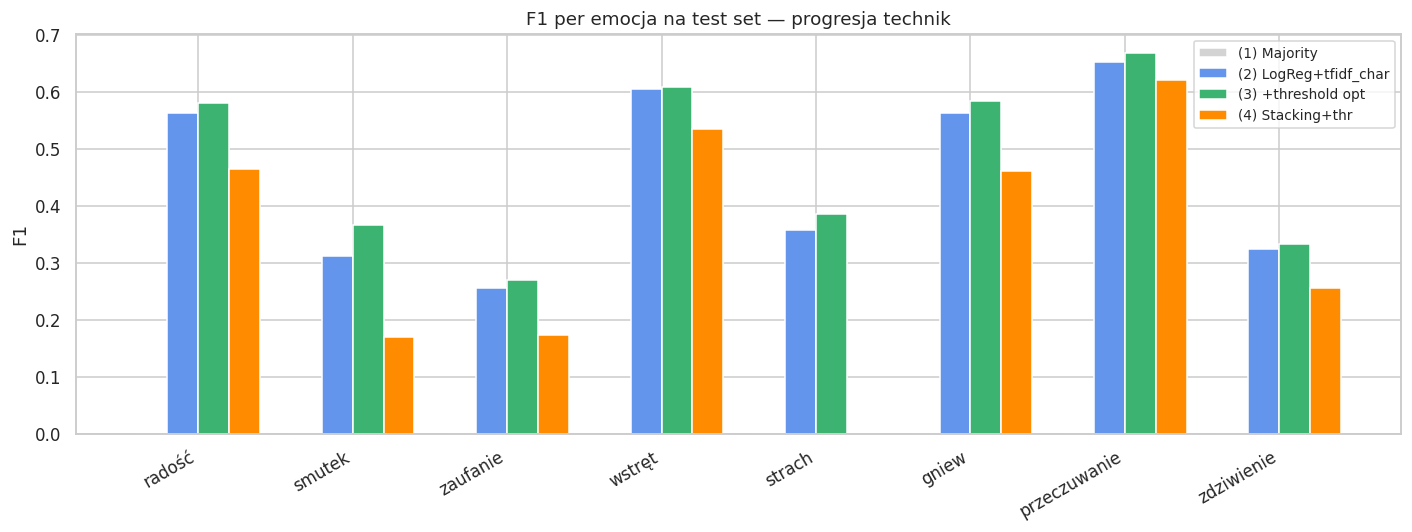

In [15]:
# Per-label final test set
final_per_label = pd.DataFrame({
    "emotion":      EMOTIONS,
    "support_test": y_tw_test.sum(axis=0),
    "f1_majority":  f1_score(y_tw_test, y_majority,                average=None, zero_division=0).round(3),
    "f1_baseline":  f1_score(y_tw_test, y_pred_best_test_default,  average=None, zero_division=0).round(3),
    "f1_thr_opt":   f1_score(y_tw_test, y_pred_best_test_opt,      average=None, zero_division=0).round(3),
    "f1_stacking":  f1_score(y_tw_test, y_pred_test_opt,           average=None, zero_division=0).round(3),
})
display(final_per_label)
final_per_label.to_csv(RESULTS_DIR / "final_per_label.csv", index=False)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(EMOTIONS))
w = 0.2
ax.bar(x - 1.5*w, final_per_label["f1_majority"], w, label="(1) Majority", color="lightgray")
ax.bar(x - 0.5*w, final_per_label["f1_baseline"], w, label=f"(2) LogReg+{best_rep}", color="cornflowerblue")
ax.bar(x + 0.5*w, final_per_label["f1_thr_opt"],  w, label="(3) +threshold opt", color="mediumseagreen")
ax.bar(x + 1.5*w, final_per_label["f1_stacking"], w, label="(4) Stacking+thr", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(EMOTIONS, rotation=30, ha="right")
ax.set_ylabel("F1")
ax.set_title("F1 per emocja na test set — progresja technik")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_per_label_test.pdf", bbox_inches="tight")
plt.show()

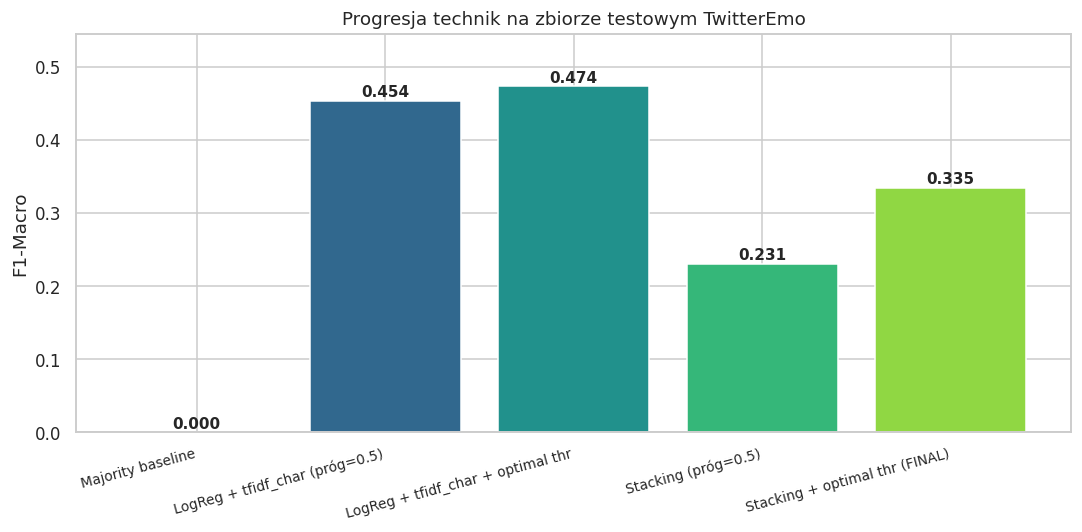

In [16]:
# Wykres progresji F1-Macro
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(final_df))
f1s = final_df["f1_macro"].values
colors = sns.color_palette("viridis", len(final_df))
bars = ax.bar(x, f1s, color=colors)
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f"{val:.3f}",
            ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([s.split(". ")[1] if ". " in s else s for s in final_df["setup"]],
                   rotation=15, ha="right", fontsize=9)
ax.set_ylabel("F1-Macro")
ax.set_title("Progresja technik na zbiorze testowym TwitterEmo")
ax.set_ylim(0, max(f1s) * 1.15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_progression.pdf", bbox_inches="tight")
plt.show()

In [17]:
# --- Log Eksp. 4-5 + wyniki końcowe to MLflow ---
log_runs_from_df(stack_df, "exp4_stacking", ["setup"], tag_cols=["setup"],
                 extra_tags={"dataset": "twitteremo", "split": "val"})
log_runs_from_df(cd_df, "exp5_transfer", ["setup"], tag_cols=["setup"],
                 extra_tags={"representation": "tfidf_char", "split": "test"})
log_runs_from_df(final_df, "final_test", ["setup"], tag_cols=["setup"],
                 extra_tags={"dataset": "twitteremo", "split": "test"})

print("Logged Eksp. 4-5 + final to MLflow.  UI:  mlflow ui --backend-store-uri file:../mlruns")

Logged Eksp. 4-5 + final to MLflow.  UI:  mlflow ui --backend-store-uri file:../mlruns


In [18]:
# --- Generate LaTeX tables ---

def df_to_latex_thesis(df: pd.DataFrame, caption: str, label: str,
                       cols_format: dict[str, str] | None = None) -> str:
    """Render DataFrame as a LaTeX table with thesis styling."""
    df_fmt = df.copy()
    if cols_format:
        for col, fmt in cols_format.items():
            if col in df_fmt.columns:
                df_fmt[col] = df_fmt[col].apply(lambda v: fmt.format(v) if pd.notna(v) else "")
    latex = df_fmt.to_latex(index=False, escape=False, column_format="l" + "c" * (len(df_fmt.columns) - 1))
    return (
        "\\begin{table}[h]\n"
        "\\centering\n"
        f"\\caption{{{caption}}}\n"
        f"\\label{{{label}}}\n"
        + latex +
        "\\end{table}\n"
    )


# Table 1: Final test set results
final_latex = final_df[["setup", "f1_macro", "f1_micro", "jaccard_macro", "hamming_loss", "subset_accuracy"]].copy()
final_latex.columns = ["Konfiguracja", "F1-Macro", "F1-Micro", "Jaccard", "Hamming", "Subset Acc."]
fmt = {c: "{:.3f}" for c in final_latex.columns[1:]}
out_latex = df_to_latex_thesis(
    final_latex,
    caption="Wyniki na zbiorze testowym TwitterEmo — progresja technik. Najlepszy wynik klasyczny: LogReg + TF-IDF char + optymalizacja progów (wiersz 3). Stacking (wiersze 4–5) to wynik negatywny — pogarsza rezultat względem pojedynczego modelu.",
    label="tab:final_results",
    cols_format=fmt,
)
(RESULTS_DIR / "table_final_results.tex").write_text(out_latex)
print("--- table_final_results.tex ---")
print(out_latex)

--- table_final_results.tex ---
\begin{table}[h]
\centering
\caption{Wyniki końcowe na zbiorze testowym TwitterEmo. Progresja technik od baseline do stacking ensemble z optymalizacją progów.}
\label{tab:final_results}
\begin{tabular}{lccccc}
\toprule
Konfiguracja & F1-Macro & F1-Micro & Jaccard & Hamming & Subset Acc. \\
\midrule
1. Majority baseline & 0.000 & 0.000 & 0.000 & 0.130 & 0.332 \\
2. LogReg + tfidf_char (próg=0.5) & 0.454 & 0.543 & 0.305 & 0.145 & 0.335 \\
3. LogReg + tfidf_char + optimal thr & 0.474 & 0.579 & 0.322 & 0.123 & 0.385 \\
4. Stacking (próg=0.5) & 0.231 & 0.435 & 0.151 & 0.114 & 0.404 \\
5. Stacking + optimal thr (FINAL) & 0.335 & 0.475 & 0.219 & 0.179 & 0.279 \\
\bottomrule
\end{tabular}
\end{table}



In [19]:
# Table 2: Per-emotion F1 progression
per_lbl_latex = final_per_label.copy()
per_lbl_latex.columns = ["Emocja", "Wsparcie", "F1 (majority)", "F1 (LogReg+TF-IDF)", "F1 (+thr)", "F1 (stacking)"]
fmt_lbl = {c: "{:.3f}" for c in per_lbl_latex.columns[2:]}
fmt_lbl["Wsparcie"] = "{:.0f}"
out_latex_lbl = df_to_latex_thesis(
    per_lbl_latex,
    caption="F1 per emocja na zbiorze testowym TwitterEmo. Wsparcie = liczba pozytywnych przykładów w teście.",
    label="tab:per_label_results",
    cols_format=fmt_lbl,
)
(RESULTS_DIR / "table_per_label.tex").write_text(out_latex_lbl)
print("--- table_per_label.tex ---")
print(out_latex_lbl)

--- table_per_label.tex ---
\begin{table}[h]
\centering
\caption{F1 per emocja na zbiorze testowym TwitterEmo. Wsparcie = liczba pozytywnych przykładów w teście.}
\label{tab:per_label_results}
\begin{tabular}{lccccc}
\toprule
Emocja & Wsparcie & F1 (majority) & F1 (LogReg+TF-IDF) & F1 (+thr) & F1 (stacking) \\
\midrule
radość & 164 & 0.000 & 0.562 & 0.580 & 0.465 \\
smutek & 67 & 0.000 & 0.311 & 0.366 & 0.169 \\
zaufanie & 64 & 0.000 & 0.256 & 0.269 & 0.173 \\
wstręt & 333 & 0.000 & 0.604 & 0.608 & 0.534 \\
strach & 13 & 0.000 & 0.357 & 0.385 & 0.000 \\
gniew & 253 & 0.000 & 0.563 & 0.583 & 0.461 \\
przeczuwanie & 504 & 0.000 & 0.652 & 0.668 & 0.621 \\
zdziwienie & 93 & 0.000 & 0.323 & 0.332 & 0.255 \\
\bottomrule
\end{tabular}
\end{table}



In [20]:
# Table 3: Best per representation
best_rep_latex = best_per_rep[["representation", "model", "f1_macro", "f1_micro", "jaccard_macro", "time_s"]].copy()
best_rep_latex.columns = ["Reprezentacja", "Model", "F1-Macro", "F1-Micro", "Jaccard", "Czas [s]"]
fmt_rep = {c: "{:.3f}" for c in ["F1-Macro", "F1-Micro", "Jaccard"]}
fmt_rep["Czas [s]"] = "{:.1f}"
out_latex_rep = df_to_latex_thesis(
    best_rep_latex,
    caption="Najlepszy klasyfikator dla każdej reprezentacji tekstu (TwitterEmo, val).",
    label="tab:best_per_representation",
    cols_format=fmt_rep,
)
(RESULTS_DIR / "table_best_per_representation.tex").write_text(out_latex_rep)
print("--- table_best_per_representation.tex ---")
print(out_latex_rep)

--- table_best_per_representation.tex ---
\begin{table}[h]
\centering
\caption{Najlepszy klasyfikator dla każdej reprezentacji tekstu (TwitterEmo, val).}
\label{tab:best_per_representation}
\begin{tabular}{lccccc}
\toprule
Reprezentacja & Model & F1-Macro & F1-Micro & Jaccard & Czas [s] \\
\midrule
tfidf_char & logreg & 0.445 & 0.542 & 0.299 & 9.3 \\
tfidf_wordchar & logreg & 0.439 & 0.547 & 0.295 & 11.1 \\
combined & logreg & 0.392 & 0.500 & 0.259 & 34.4 \\
tfidf_word & logreg & 0.374 & 0.474 & 0.243 & 0.7 \\
fasttext & hist_gb & 0.334 & 0.420 & 0.216 & 9.6 \\
lsa & hist_gb & 0.314 & 0.403 & 0.199 & 15.2 \\
stats & hist_gb & 0.278 & 0.331 & 0.173 & 1.4 \\
nrc & hist_gb & 0.241 & 0.282 & 0.144 & 1.3 \\
lda & hist_gb & 0.230 & 0.276 & 0.137 & 1.3 \\
\bottomrule
\end{tabular}
\end{table}



In [21]:
# Table 4: Cross-dataset
cd_latex = cd_df[["setup", "f1_macro", "f1_micro", "jaccard_macro", "hamming_loss"]].copy()
cd_latex.columns = ["Scenariusz", "F1-Macro", "F1-Micro", "Jaccard", "Hamming"]
fmt_cd = {c: "{:.3f}" for c in cd_latex.columns[1:]}
out_latex_cd = df_to_latex_thesis(
    cd_latex,
    caption="Macierz transferu 3×3 (TwitterEmo / GoEmotions PL / CLARIN-Emo). Wiersz = zbiór treningowy, kolumna = zbiór ewaluacyjny (test). Wspólny TF-IDF char(3,5) na połączonym korpusie, LogReg, progi strojone na val zbioru treningowego, train podpróbkowany do równego N.",
    label="tab:cross_dataset",
    cols_format=fmt_cd,
)
(RESULTS_DIR / "table_cross_dataset.tex").write_text(out_latex_cd)
print("--- table_cross_dataset.tex ---")
print(out_latex_cd)

--- table_cross_dataset.tex ---
\begin{table}[h]
\centering
\caption{Macierz transferu 3×3 (TwitterEmo / GoEmotions PL / CLARIN-Emo). Wiersz = zbiór treningowy, kolumna = zbiór ewaluacyjny (test). Wspólny TF-IDF char(3,5) na połączonym korpusie, LogReg, progi strojone na val zbioru treningowego, train podpróbkowany do równego N.}
\label{tab:cross_dataset}
\begin{tabular}{lcccc}
\toprule
Scenariusz & F1-Macro & F1-Micro & Jaccard & Hamming \\
\midrule
TW → TW (in-domain) & 0.375 & 0.519 & 0.246 & 0.143 \\
TW → GO (transfer) & 0.214 & 0.289 & 0.130 & 0.169 \\
TW → CE (transfer) & 0.206 & 0.261 & 0.119 & 0.213 \\
GO → TW (transfer) & 0.184 & 0.195 & 0.110 & 0.164 \\
GO → GO (in-domain) & 0.446 & 0.497 & 0.297 & 0.114 \\
GO → CE (transfer) & 0.182 & 0.227 & 0.105 & 0.213 \\
CE → TW (transfer) & 0.216 & 0.259 & 0.127 & 0.249 \\
CE → GO (transfer) & 0.212 & 0.239 & 0.123 & 0.244 \\
CE → CE (in-domain) & 0.529 & 0.626 & 0.376 & 0.173 \\
\bottomrule
\end{tabular}
\end{table}

